In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_derivative),
    "relu": (relu, relu_derivative),
    "softmax": (softmax, None),  # derivative handled in loss
}

def shuffle(X,Y):
    index = np.arange(X.shape[0])
    np.random.shuffle(index)
    return X[index,:], Y[index]

In [3]:
class Loss:
    def forward(self, y_hat, y):
        raise NotImplementedError

    def backward(self, y_hat, y):
        raise NotImplementedError


class MSELoss(Loss):
    def forward(self, y_hat, y):
        return np.mean((y_hat - y) ** 2)

    def backward(self, y_hat, y):
        return 2 * (y_hat - y) / y.shape[0]


class BinaryCrossEntropy(Loss):
    def forward(self, y_hat, y):
        eps = 1e-8
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def backward(self, y_hat, y):
        return (y_hat - y) / y.shape[0]


class CategoricalCrossEntropy(Loss):
    def forward(self, y_hat, y):
        eps = 1e-8
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(np.sum(y * np.log(y_hat), axis=1))

    def backward(self, y_hat, y):
        # softmax + CE simplification
        return (y_hat - y) / y.shape[0]

In [4]:
class DenseLayer:
    def __init__(self, input_dim, output_dim, activation="relu"):
        self.W = np.random.randn(input_dim, output_dim) * np.sqrt(2 / input_dim)
        self.b = np.zeros((1, output_dim))

        self.activation_name = activation
        self.activation, self.activation_prime = ACTIVATIONS[activation]

        self.Z = None
        self.A_prev = None

        self.vW = np.zeros_like(self.W)
        self.vb = np.zeros_like(self.b)

    def forward(self, A_prev):
        self.A_prev = A_prev
        self.Z = A_prev @ self.W + self.b
        return self.activation(self.Z)

    def backward(self, dA, lr, mom):
        if self.activation_name == "softmax":
            dZ = dA
        else:
            dZ = dA * self.activation_prime(self.Z)

        m = self.A_prev.shape[0]
        dW = (self.A_prev.T @ dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m
        dA_prev = dZ @ self.W.T

        self.vW = mom * self.vW - lr * dW
        self.vb = mom * self.vb - lr * db

        self.W += self.vW
        self.b += self.vb

        return dA_prev

In [5]:
class NeuralNetwork:
    def __init__(self, layer_dims, activations, loss):
        assert len(layer_dims) - 1 == len(activations)

        self.layers = []
        for i in range(len(layer_dims) - 1):
            self.layers.append(
                DenseLayer(
                    layer_dims[i],
                    layer_dims[i + 1],
                    activation=activations[i],
                )
            )

        if loss == "mse":
            self.loss = MSELoss()
        elif loss == "bce":
            self.loss = BinaryCrossEntropy()
        elif loss == "cce":
            self.loss = CategoricalCrossEntropy()
        else:
            raise ValueError("Unsupported loss")

        self.acc_train = []
        self.acc_test = []    
        
    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def train(self, X, Y, X2, Y2, epochs=100, batch_size=32, 
              lr=0.01, mom=0.9,verbose=True):
        n = X.shape[0]

        for epoch in range(epochs):
            perm = np.random.permutation(n)
            Xs, Ys = X[perm], Y[perm]

            for i in range(0, n, batch_size):
                Xb = Xs[i : i + batch_size]
                Yb = Ys[i : i + batch_size]

                Y_hat = self.forward(Xb)
                dA = self.loss.backward(Y_hat, Yb)

                for layer in reversed(self.layers):
                    dA = layer.backward(dA, lr, mom)

            if verbose and (epoch+1) % 20 == 0:
                loss_val = self.loss.forward(self.forward(X), Y)
                print(f"Epoch {epoch+1:4d} | Loss: {loss_val:.6f}")
                
                y_prob1 = np.argmax(nn.forward(X), axis=1)
                y_true1 = np.argmax(Y, axis=1)
                temp1 = np.mean(1.0*(y_prob1==y_true1))
                self.acc_train.append(temp1)
                
                y_prob2 = np.argmax(nn.forward(X2), axis=1)
                y_true2 = np.argmax(Y2, axis=1)
                temp2 = np.mean(1.0*(y_prob2==y_true2))
                self.acc_test.append(temp2)
                
                

    def predict(self, X):
        """
        Returns:
        - regression: raw outputs
        - binary classification: {0,1}
        - multiclass: class indices
        """
        Y_hat = self.forward(X)

        if isinstance(self.loss, MSELoss):
            return Y_hat

        if isinstance(self.loss, BinaryCrossEntropy):
            return (Y_hat >= 0.5).astype(int)

        if isinstance(self.loss, CategoricalCrossEntropy):
            return np.argmax(Y_hat, axis=1)

    def predict_proba(self, X, temperature=1.0):
        Z = self.forward(X)
        if isinstance(self.loss, CategoricalCrossEntropy):
            Z = Z / temperature
            return softmax(Z)
        return Z

In [ ]:
#I have different file names for the datasets, and ran the DNN locally
import idx2numpy

path = ''

def plot_image(k):
    plt.imshow(train_images[k], cmap='gray')
    plt.title(f"Label: {train_labels[k]}")
    plt.show()

def plot_image2(myarray):
    plt.imshow(myarray, cmap='gray')
    plt.show()


# File paths (ensure you have the files downloaded and unzipped)
train_images_file = 'train-images.idx3-ubyte'
train_labels_file = 'train-labels.idx1-ubyte'
test_images_file = 't10k-images.idx3-ubyte'
test_labels_file = 't10k-labels.idx1-ubyte'

# Convert from file to NumPy array
train_images = idx2numpy.convert_from_file(path+train_images_file)
train_labels = idx2numpy.convert_from_file(path+train_labels_file)
test_images = idx2numpy.convert_from_file(path+test_images_file)
test_labels = idx2numpy.convert_from_file(path+test_labels_file)

# You can then check the shapes
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)


In [8]:
X = train_images.reshape((-1, 784))/255
X = X-np.mean(X, axis=0, keepdims=True)

Y = np.zeros((train_labels.shape[0],10))
for i, j in enumerate(train_labels):
    Y[i,j]=1

X2 = test_images.reshape((-1, 784))/255
X2 = X2-np.mean(X2, axis=0, keepdims=True)

Y2 = np.zeros((test_labels.shape[0],10))
for i, j in enumerate(test_labels):
    Y2[i,j]=1


In [ ]:
%%time

# X: (N, d)
# Y: (N, C) one-hot

nn = NeuralNetwork(
    layer_dims=[784, 32, 32, 10],
    activations=["relu", "relu", "softmax"],
    loss="cce",
)

nn.train(X, Y, X2, Y2, epochs=2000, batch_size=200, lr=0.05)
#Took about ~1hr on CPU on my laptop


Epoch   20 | Loss: 0.375400
Epoch   40 | Loss: 0.278104
Epoch   60 | Loss: 0.232663
Epoch   80 | Loss: 0.204327
Epoch  100 | Loss: 0.184597
Epoch  120 | Loss: 0.169659
Epoch  140 | Loss: 0.157727
Epoch  160 | Loss: 0.147794
Epoch  180 | Loss: 0.139311
Epoch  200 | Loss: 0.131922
Epoch  220 | Loss: 0.125375
Epoch  240 | Loss: 0.119501
Epoch  260 | Loss: 0.114213
Epoch  280 | Loss: 0.109428
Epoch  300 | Loss: 0.105028
Epoch  320 | Loss: 0.100965
Epoch  340 | Loss: 0.097204
Epoch  360 | Loss: 0.093711
Epoch  380 | Loss: 0.090452
Epoch  400 | Loss: 0.087393
Epoch  420 | Loss: 0.084527
Epoch  440 | Loss: 0.081844
Epoch  460 | Loss: 0.079318
Epoch  480 | Loss: 0.076934
Epoch  500 | Loss: 0.074689
Epoch  520 | Loss: 0.072560
Epoch  540 | Loss: 0.070527
Epoch  560 | Loss: 0.068595
Epoch  580 | Loss: 0.066754
Epoch  600 | Loss: 0.064998
Epoch  620 | Loss: 0.063327
Epoch  640 | Loss: 0.061729
Epoch  660 | Loss: 0.060194
Epoch  680 | Loss: 0.058713
Epoch  700 | Loss: 0.057286
Epoch  720 | Loss: 0

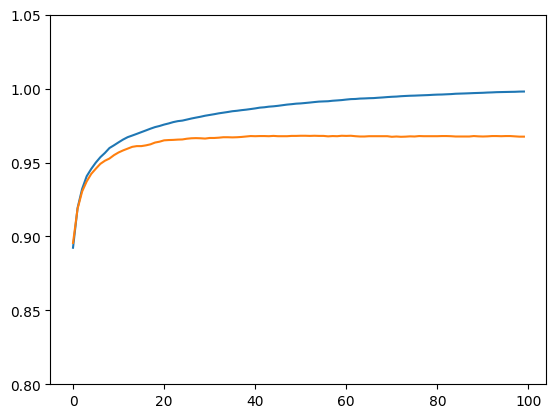

In [10]:
plt.plot(nn.acc_train)
plt.plot(nn.acc_test)
plt.ylim(.8,1.05)
plt.show()

0 (100, 100)
1 (100, 100)
2 (100, 100)
3 (100, 100)
4 (100, 100)
5 (100, 100)
6 (100, 100)
7 (100, 100)
8 (100, 100)
9 (100, 100)


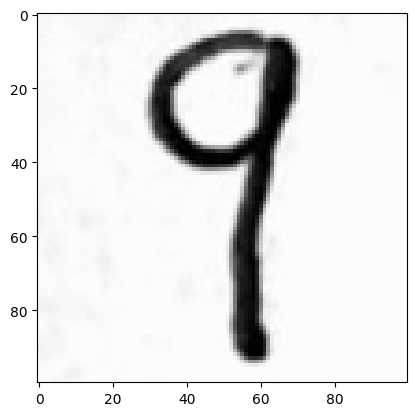

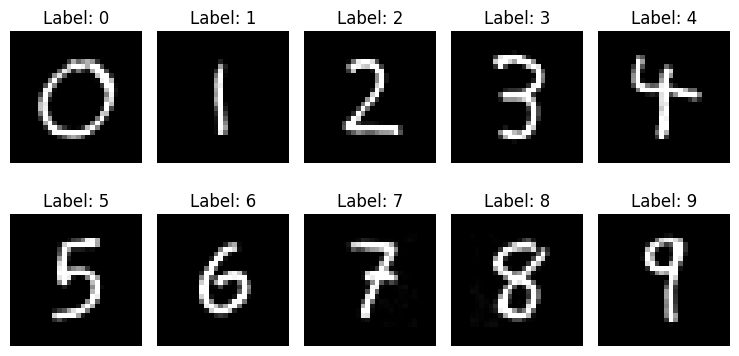

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


#I scanned the digits 0-9 written in black pen, then screenshotted the document and imported it

img = Image.open('dnnmnistscan.jpg')
img = img.convert('L')
img = np.array(img)
img.shape


#Screenshot is tight around numbers
plt.imshow(img[:,:], cmap='gray')


# Game Plan:
# I'm making each image 200x200 so that I can reduce to 20x20 easily
# then I will add a padding of 4 pixels around the 20x20 to get 28x28
# Also I need to reverse the values because the writing needs to be
# white and the background to be black to be consistent with MNIST

#Used similar plan, lower quality didn't seem to matter
#Each of the 10 images were individually centered and zoomed(below)

ran = 100
cor = (140,140)
img0 = img[30:30+ran,40:40+ran]
plt.imshow(img0, cmap='gray')


ran = 100
cor = (140,340)
img1 = img[30:30+ran,175:175+ran]
plt.imshow(img1, cmap='gray')


ran = 100
cor = (140,590)
img2 = img[28:28+ran,285:285+ran]
plt.imshow(img2, cmap='gray')


ran = 100
cor = (125,850)
img3 = img[30:30+ran,410:410+ran]
plt.imshow(img3, cmap='gray')


ran = 100
cor = (140,1120)
img4 = img[28:28+ran,525:525+ran]
plt.imshow(img4, cmap='gray')


ran = 100
cor = (120,1340)
img5 = img[25:25+ran,635:635+ran]
plt.imshow(img5, cmap='gray')


ran = 100
cor = (130,1565)
img6 = img[22:22+ran,745:745+ran]
plt.imshow(img6, cmap='gray')


ran = 100
cor = (130,1820)
img7 = img[27:27+ran,855:855+ran]
plt.imshow(img7, cmap='gray')


ran = 100
cor = (140,2050)
img8 = img[30:30+ran,950:950+ran]
plt.imshow(img8, cmap='gray')


ran = 100
cor = (155,2270)
img9 = img[33:33+ran,1060:1060+ran]
plt.imshow(img9, cmap='gray')


images = [img0,img1,img2,img3,img4,img5,img6,img7,img8,img9]
for i, item in enumerate(images):
    print(i,item.shape)


images2 = []
for i, item in enumerate(images):
    img = Image.fromarray(item)
    img = img.resize((20, 20), Image.BILINEAR)
    img = np.array(img)
    # Need to reverse the numbers since black is 0 and white is 255
    # Took me a while to find good values, I tried to make the images detect as much pen as possible
    img2 = (255-(255/140)*(np.clip(img,100,240)-100)).astype(int)
    img2 = np.pad(img2,pad_width=4,mode="constant",constant_values=0)
    images2.append(img2)


num_row = 2
num_col = 5
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col, 2*num_row))


# Plot each image
for i in range(10):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(images2[i], cmap='gray')
    ax.set_title(f"Label: {i}")
    ax.axis('off') # Hide the axis ticks


plt.tight_layout() # Adjust subplot params so that the subplot(s) fits in to the figure
plt.show()






In [ ]:
count = 0
correct = 0
for i in images2:
    print(count, "has predicted label:", nn.predict(i.reshape((-1, 784))/255), end="")
    count+=1
    if count - 1 == nn.predict(i.reshape((-1, 784))/255)[0]:
        print(", Correct!")
        correct+=1
    else:
        print(", Incorrect...")
print(correct, "/ 10")


#Lots of tweeking with the image processing was done, this is the best I can seem to get it,
#drawing the 1 with the top and bottom, or the 7 without the strikethrough may have helped


0 has predicted label: [0], Correct!
1 has predicted label: [8], Incorrect...
2 has predicted label: [2], Correct!
3 has predicted label: [3], Correct!
4 has predicted label: [4], Correct!
5 has predicted label: [5], Correct!
6 has predicted label: [6], Correct!
7 has predicted label: [3], Incorrect...
8 has predicted label: [8], Correct!
9 has predicted label: [9], Correct!
8 / 10
